# Actividad 2
**Análisis de Datos 2 | Franco Curcho**


In [9]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

RANDOM_STATE = 42
VARIABLES = ['salary_in_usd', 'experience_level', 'remote_ratio', 'company_size']
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.figsize': (9, 5), 'axes.spines.top': False, 'axes.spines.right': False})
print('Python:', sys.version.split()[0], '| pandas:', pd.__version__, '| sklearn:', sklearn.__version__)
paths = [Path('ds_salaries.csv'), Path('upload/ds_salaries.csv'), Path('../upload/ds_salaries.csv')]
DATA_PATH = next((p for p in paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('Colocar ds_salaries.csv junto al notebook.')
raw = pd.read_csv(DATA_PATH)
print('Dimensión original:', raw.shape)
display(raw.head())

Python: 3.11.16 | pandas: 3.0.5 | sklearn: 1.9.0
Dimensión original: (3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## 1. Preparación y selección de variables
Se eligen salario en USD (objetivo), nivel de experiencia, modalidad remota y tamaño de empresa (predictores). El salario en moneda original no es comparable entre países; se utiliza `salary_in_usd`. `remote_ratio` toma tres modalidades: 0 presencial, 50 híbrido y 100 remoto.

La auditoría de calidad se hace **antes de eliminar duplicados**. Se mantiene el índice original del CSV para poder localizar cada anomalía. Una fila idéntica no demuestra una carga errónea: puede representar personas diferentes. Se deduplica por continuidad metodológica con la Actividad 1, explicitando que se analiza una población de combinaciones únicas y que ello altera las frecuencias.

In [10]:
def split_periods(data):
    return data[data.work_year.isin([2020, 2021])].copy(), data[data.work_year.isin([2022, 2023])].copy()

ref_raw, cur_raw = split_periods(raw)
df = raw.drop_duplicates().copy()
ref, cur = split_periods(df)
display(pd.DataFrame({
    'Original': [len(ref_raw), len(cur_raw)],
    'Sin duplicados': [len(ref), len(cur)]
}, index=['Referencia 2020–2021', 'Actual 2022–2023']))
assert len(ref) + len(cur) == len(df)
print('Duplicados eliminados:', len(raw)-len(df))

,Original,Sin duplicados
Referencia 2020–2021,306,303
Actual 2022–2023,3449,2281


Duplicados eliminados: 1171


## 2. Calidad de datos 
Se aplican cuatro controles de calidad:
1. **Completitud:** ausencia de nulos o cadenas vacías.
2. **Validez de dominio:** salario positivo y finito, experiencia EN/MI/SE/EX, modalidad 0/50/100 y empresa S/M/L.
3. **Esquema:** tipos numéricos o textuales esperados.
4. **Unicidad:** repeticiones exactas de filas completas. No se exige unicidad de las cuatro variables, porque es normal que varios trabajadores compartan esos atributos.


In [11]:
allowed = {'experience_level': ['EN','MI','SE','EX'], 'remote_ratio': [0,50,100], 'company_size': ['S','M','L']}
checks = []
for period, data in [('Referencia', ref_raw), ('Actual', cur_raw)]:
    for col in VARIABLES:
        empty = data[col].isna() | data[col].astype(str).str.strip().eq('')
        if col == 'salary_in_usd':
            vals = pd.to_numeric(data[col], errors='coerce')
            invalid = ~(np.isfinite(vals) & vals.gt(0))
        else:
            invalid = ~data[col].isin(allowed[col])
        expected_numeric = col in ['salary_in_usd','remote_ratio']
        schema_ok = (pd.api.types.is_numeric_dtype(data[col]) if expected_numeric
                     else data[col].dropna().map(lambda v: isinstance(v,str)).all())
        checks.append([period,col,int(empty.sum()),int(invalid.sum()),bool(schema_ok)])
display(pd.DataFrame(checks, columns=['Período','Variable','Faltantes/vacíos','Fuera de dominio','Esquema válido']))
display(pd.DataFrame({
    'Filas repetidas (después de la primera)': [ref_raw.duplicated().sum(), cur_raw.duplicated().sum()],
    'Porcentaje': [100*ref_raw.duplicated().mean(),100*cur_raw.duplicated().mean()]
}, index=['Referencia','Actual']))
usd = raw[raw.salary_currency.eq('USD')]
print('Inconsistencias salary vs salary_in_usd para USD:', int((~np.isclose(usd.salary,usd.salary_in_usd)).sum()))

,Período,Variable,Faltantes/vacíos,Fuera de dominio,Esquema válido
0,Referencia,salary_in_usd,0,0,True
1,Referencia,experience_level,0,0,True
2,Referencia,remote_ratio,0,0,True
3,Referencia,company_size,0,0,True
4,Actual,salary_in_usd,0,0,True
5,Actual,experience_level,0,0,True
6,Actual,remote_ratio,0,0,True
7,Actual,company_size,0,0,True


,Filas repetidas (después de la primera),Porcentaje
Referencia,3,0.9804
Actual,1168,33.8649


Inconsistencias salary vs salary_in_usd para USD: 0


## 3. PSI 

Para el salario se usan 10 intervalos definidos **solo con los cuantiles de referencia**. Se reutilizan exactamente los mismos intervalos al comparar períodos. Para las demás variables se usan sus categorías. Se aplica un piso de $10^{-6}$ y renormalización si aparecen ceros.

Se adoptan los umbrales orientativos de la clase 3: PSI < 0,10 sin alerta; 0,10 ≤ PSI < 0,25 cambio moderado; PSI ≥ 0,25 cambio importante.

,PSI,Resultado,Qué cambia
salary_in_usd,0.6722,Importante,P(Y): distribución salarial
experience_level,0.5333,Importante,P(X): experiencia
remote_ratio,0.9481,Importante,P(X): modalidad remota
company_size,1.8506,Importante,P(X): tamaño de empresa


salary_in_usd


,Referencia,Actual,Contribución PSI
salary_in_usd,,,
"(-inf, 19687.2]",0.1023,0.0175,0.1495
"(19687.2, 37115.8]",0.0990,0.0219,0.1162
"(37115.8, 50108.0]",0.0990,0.0329,0.0729
"(50108.0, 63826.8]",0.0990,0.0495,0.0343
"(63826.8, 79833.0]",0.1056,0.0644,0.0203
"(79833.0, 93432.8]",0.0957,0.0614,0.0153
"(93432.8, 110732.2]",0.0990,0.1100,0.0012
"(110732.2, 141107.6]",0.0990,0.1894,0.0586
"(141107.6, 184000.0]",0.0990,0.2231,0.1009


experience_level


,Referencia,Actual,Contribución PSI
experience_level,,,
EN,0.2541,0.0846,0.1864
EX,0.0429,0.0364,0.0011
MI,0.4026,0.2376,0.0870
SE,0.3003,0.6414,0.2588


remote_ratio


,Referencia,Actual,Contribución PSI
remote_ratio,,,
0,0.1650,0.4980,0.3678
50,0.3168,0.0399,0.5738
100,0.5182,0.4621,0.0064


company_size


,Referencia,Actual,Contribución PSI
company_size,,,
L,0.5248,0.1096,0.6502
M,0.2376,0.8575,0.7955
S,0.2376,0.0329,0.4049


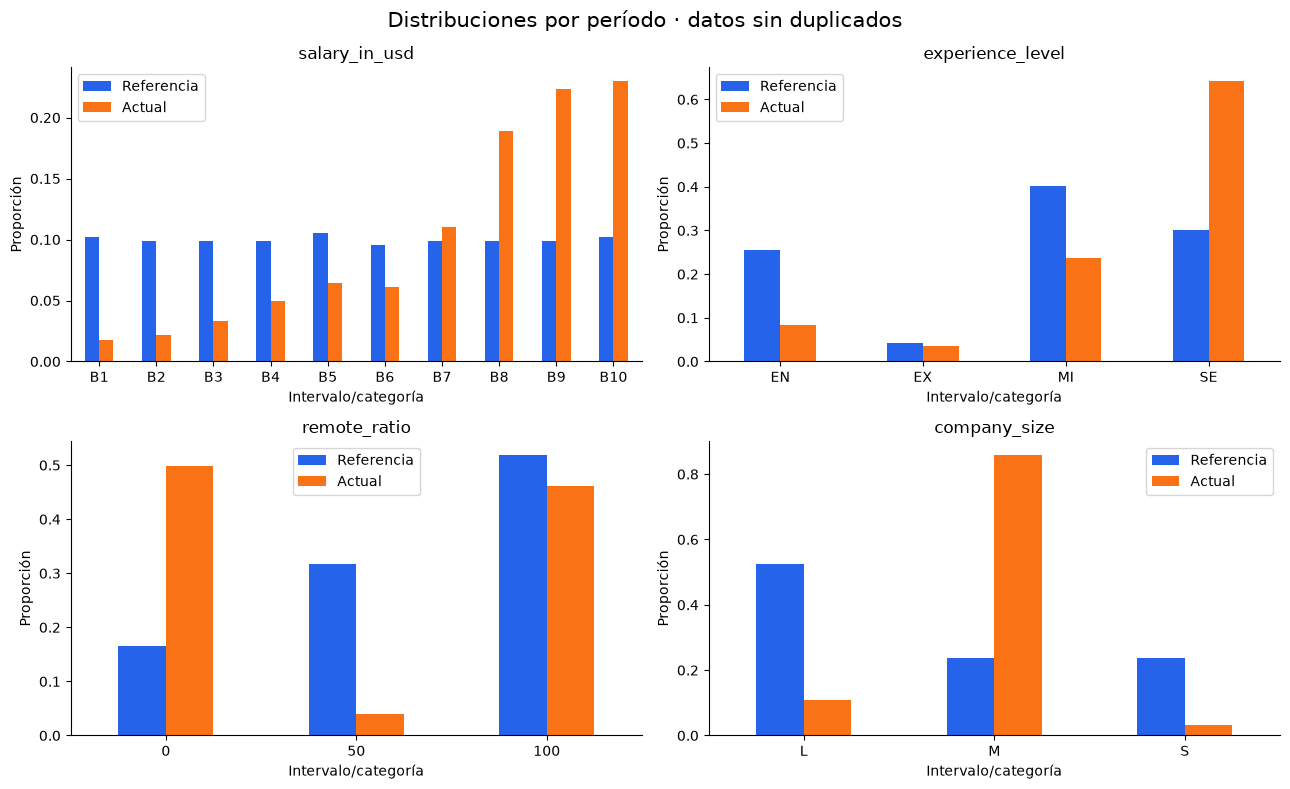

In [12]:
def psi_table(a, b, col, bins_count=10):
    if col == 'salary_in_usd':
        edges = np.unique(np.quantile(a[col], np.linspace(0,1,bins_count+1)))
        edges[0], edges[-1] = -np.inf, np.inf
        p = pd.cut(a[col], edges, include_lowest=True).value_counts(sort=False, normalize=True)
        q = pd.cut(b[col], edges, include_lowest=True).value_counts(sort=False, normalize=True)
    else:
        cats = sorted(set(a[col]) | set(b[col]))
        p = a[col].value_counts(normalize=True).reindex(cats,fill_value=0)
        q = b[col].value_counts(normalize=True).reindex(cats,fill_value=0)
    pp, qq = p.clip(lower=1e-6), q.clip(lower=1e-6)
    pp, qq = pp/pp.sum(), qq/qq.sum()
    return pd.DataFrame({'Referencia':p,'Actual':q,'Contribución PSI':(qq-pp)*np.log(qq/pp)})

def label(v):
    return 'Importante' if v >= .25 else ('Moderado' if v >= .1 else 'Sin alerta')

tables = {v:psi_table(ref,cur,v) for v in VARIABLES}
summary = pd.DataFrame({'PSI':{v:t['Contribución PSI'].sum() for v,t in tables.items()}})
summary['Resultado'] = summary.PSI.map(label)
summary['Qué cambia'] = ['P(Y): distribución salarial','P(X): experiencia','P(X): modalidad remota','P(X): tamaño de empresa']
display(summary)
for v,t in tables.items():
    print(v)
    display(t)
fig, axes = plt.subplots(2,2,figsize=(13,8))
for ax,(v,t) in zip(axes.flat,tables.items()):
    plot = t[['Referencia','Actual']].copy()
    if v == 'salary_in_usd':
        plot.index = [f'B{i+1}' for i in range(len(plot))]
    plot.plot.bar(ax=ax,color=['#2563eb','#f97316'],rot=0)
    ax.set(title=v,ylabel='Proporción',xlabel='Intervalo/categoría')
fig.suptitle('Distribuciones por período · datos sin duplicados',fontsize=15)
plt.tight_layout()
plt.show()

In [13]:
sensitivity = summary[['PSI']].rename(columns={'PSI':'Sin duplicados'})
sensitivity['Con duplicados'] = [psi_table(ref_raw,cur_raw,v)['Contribución PSI'].sum() for v in VARIABLES]
sensitivity['Conclusión coincide'] = sensitivity['Sin duplicados'].map(label).eq(sensitivity['Con duplicados'].map(label))
display(sensitivity)
display(pd.DataFrame({f'{k} intervalos': [psi_table(ref,cur,'salary_in_usd',k)['Contribución PSI'].sum()] for k in [5,10,15]},index=['PSI salario']))
display(pd.DataFrame({'Referencia':ref.salary_in_usd.describe(),'Actual':cur.salary_in_usd.describe()}))

,Sin duplicados,Con duplicados,Conclusión coincide
salary_in_usd,0.6722,0.8701,True
experience_level,0.5333,0.7417,True
remote_ratio,0.9481,1.1914,True
company_size,1.8506,2.1981,True


,5 intervalos,10 intervalos,15 intervalos
PSI salario,0.6465,0.6722,0.7182


,Referencia,Actual
count,303.0000,"2,281.0000"
mean,"93,567.0990","138,701.7751"
std,"72,078.3513","64,646.9718"
min,"5,409.0000","5,132.0000"
25%,"45,586.5000","93,919.0000"
50%,"79,833.0000","135,000.0000"
75%,"120,000.0000","180,000.0000"
max,"450,000.0000","430,967.0000"


### Interpretación del tipo de drift
- Las diferencias en experiencia, modalidad y empresa evidencian cambios marginales de las entradas P(X), compatibles con data drift. Para afirmar *covariate shift* en sentido estricto habría que comprobar además que P(Y|X) permanece estable.
- El cambio salarial evidencia cambio marginal del objetivo P(Y). Es compatible con target drift, pero no demuestra *label shift* puro, que exige estabilidad de P(X|Y).
- **No se demuestra concept drift**: el PSI no evalúa si cambió la relación condicional entre salario y predictores. Sería necesario analizar errores y relaciones por período, controlando la composición de las muestras.

Las cuatro variables superan 0,25: salario 0,6722; experiencia 0,5333; modalidad remota 0,9481; tamaño de empresa 1,8506. Los perfiles senior pasan de 30,0% a 64,1%; la modalidad híbrida cae de 31,7% a 4,0%; las empresas medianas aumentan de 23,8% a 85,8%. La mediana salarial pasa de USD 79.833 a USD 135.000. 

La conclusión de cambio importante se mantiene con duplicados y con 5, 10 y 15 intervalos salariales. Por tanto, no depende exclusivamente de la deduplicación ni del número de intervalos probado.

## 4. Estrategia para el modelo de la Actividad 1
**Elección: reentrenamiento.**

El modelo pertinente es el Random Forest, excluyendo `salary` y `salary_currency`. En la Actividad 1 se reportaron MAE ≈ USD 38.577 y R² ≈ 0,368 sobre un split aleatorio. Son resultados históricos de ese notebook; no se vuelven a estimar aquí ni se interpretan como una medición de deterioro temporal.


**Procedimiento propuesto:**
1. Reconstruir el pipeline sin leakage y entrenar una versión histórica con 2020–2021.
2. Entrenar una candidata con 2022 (o una ventana histórica con mayor peso reciente).
3. Comparar ambas sobre el mismo conjunto 2023 reservado, usando MAE, RMSE y errores por experiencia y modalidad. Ajustar hiperparámetros únicamente dentro de los períodos de entrenamiento.
4. Adoptar la candidata solo si mejora de forma suficientemente consistente; luego monitorear calidad, PSI y error cuando estén disponibles las etiquetas.



## 5. Detección de anomalías
Se analizan las mismas cuatro variables. El salario se estandariza; experiencia, tamaño y modalidad se codifican con one-hot, sin imponer distancias ordinales arbitrarias. Usar salario aquí es válido: se auditan registros completos, no se intenta predecir un salario desconocido.

Se aplica Isolation Forest con 300 árboles y LOF con 20 vecinos. Se fija `contamination=0.05` como presupuesto exploratorio de revisión. 

LOF depende de las distancias y puede ser sensible a combinaciones repetidas aun después de deduplicar filas completas.

In [14]:
pre = ColumnTransformer([
    ('salary',StandardScaler(),['salary_in_usd']),
    ('categories',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['experience_level','remote_ratio','company_size'])
])
Z = pre.fit_transform(df[VARIABLES])
iso = IsolationForest(n_estimators=300,contamination=.05,random_state=RANDOM_STATE,n_jobs=1)
lof = LocalOutlierFactor(n_neighbors=20,contamination=.05,n_jobs=1)
results = df.copy()
results['IF_anomalia'] = iso.fit_predict(Z) == -1
results['LOF_anomalia'] = lof.fit_predict(Z) == -1
results['IF_score'] = -iso.score_samples(Z)
results['LOF_score'] = -lof.negative_outlier_factor_
print('Dimensión de la matriz:',Z.shape)
print('Filas repetidas en las cuatro variables:',df[VARIABLES].duplicated().sum())
display(pd.DataFrame({'Anomalías':results[['IF_anomalia','LOF_anomalia']].sum(),'Porcentaje':100*results[['IF_anomalia','LOF_anomalia']].mean()}))
display(pd.crosstab(results.IF_anomalia,results.LOF_anomalia,rownames=['Isolation Forest'],colnames=['LOF']))
union = (results.IF_anomalia | results.LOF_anomalia).sum()
intersection = (results.IF_anomalia & results.LOF_anomalia).sum()
print(f'Coincidencia sobre la unión (Jaccard): {intersection/union:.3f}')

Dimensión de la matriz: (2584, 11)
Filas repetidas en las cuatro variables: 924


,Anomalías,Porcentaje
IF_anomalia,130,5.0310
LOF_anomalia,130,5.0310


LOF,False,True
Isolation Forest,,
False,2360,94
True,94,36


Coincidencia sobre la unión (Jaccard): 0.161


## 6. Registro concreto e interpretación
Para evitar una elección ambigua, se selecciona el salario máximo entre los registros marcados por al menos un método. Se muestra su índice original (base cero) y se compara con el criterio univariado IQR: por encima de Q3 + 1,5·IQR o por debajo de Q1 − 1,5·IQR. Ser identificado por un algoritmo multivariado no prueba que la anomalía sea exclusivamente multivariada.

Índice original: 3522 | línea del CSV (incluyendo encabezado): 3524


,Valor
work_year,2020
experience_level,MI
employment_type,FT
job_title,Research Scientist
salary,450000
salary_currency,USD
salary_in_usd,450000
employee_residence,US
remote_ratio,0
company_location,US


Q1=84,975; Q3=175,000; IQR=90,025; límites=[-50,062, 310,038] USD
Outlier univariado salarial: True
Registros con igual experiencia, modalidad y tamaño: 267


,Salarios del grupo
count,267.0000
mean,"118,934.1498"
std,"57,096.3277"
min,"10,000.0000"
25%,"79,589.0000"
50%,"109,006.0000"
75%,"147,750.0000"
max,"450,000.0000"


c:\Users\franc\miniconda3\envs\add2-env\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,Vecinos LOF,Caso anómalo,Score LOF
0,10,False,1.8029
1,20,True,1.8951
2,35,False,2.1390
3,50,False,2.4372


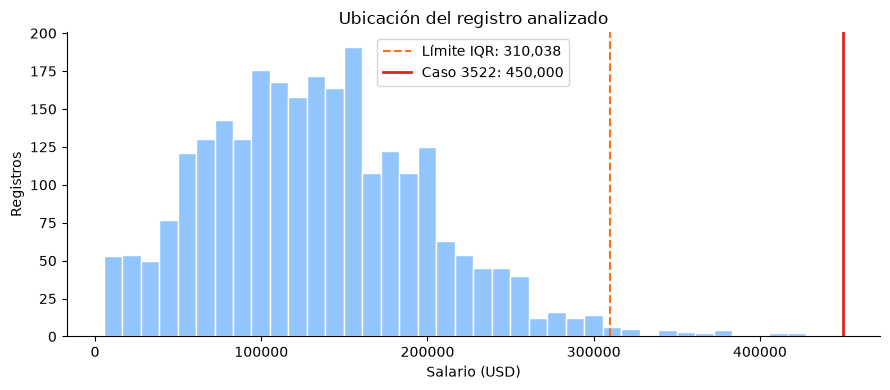

**Resultado:** el registro 3522, Research Scientist, tiene salario de **USD 450,000**, experiencia **MI**, modalidad **0%** y empresa **M**. Isolation Forest lo marca: **False**; LOF lo marca: **True**. Supera el criterio univariado salarial: **True**.

In [15]:
flagged = results[results.IF_anomalia | results.LOF_anomalia]
case_id = flagged.salary_in_usd.idxmax()
case = results.loc[case_id]
q1,q3 = df.salary_in_usd.quantile([.25,.75])
iqr = q3-q1
lower,upper = q1-1.5*iqr,q3+1.5*iqr
univariate = not (lower <= case.salary_in_usd <= upper)
print('Índice original:',case_id, '| línea del CSV (incluyendo encabezado):',case_id+2)
display(case.to_frame('Valor'))
print(f'Q1={q1:,.0f}; Q3={q3:,.0f}; IQR={iqr:,.0f}; límites=[{lower:,.0f}, {upper:,.0f}] USD')
print('Outlier univariado salarial:',univariate)
context = df[(df.experience_level==case.experience_level)&(df.remote_ratio==case.remote_ratio)&(df.company_size==case.company_size)]
print('Registros con igual experiencia, modalidad y tamaño:',len(context))
display(context.salary_in_usd.describe().to_frame('Salarios del grupo'))
stability=[]
for k in [10,20,35,50]:
    other=LocalOutlierFactor(n_neighbors=k,contamination=.05,n_jobs=1)
    flags=other.fit_predict(Z)
    pos=df.index.get_loc(case_id)
    stability.append([k,flags[pos]==-1,-other.negative_outlier_factor_[pos]])
display(pd.DataFrame(stability,columns=['Vecinos LOF','Caso anómalo','Score LOF']))
fig,ax=plt.subplots(figsize=(9,4))
ax.hist(df.salary_in_usd,bins=40,color='#93c5fd',edgecolor='white')
ax.axvline(upper,color='#f97316',ls='--',label=f'Límite IQR: {upper:,.0f}')
ax.axvline(case.salary_in_usd,color='#dc2626',lw=2,label=f'Caso {case_id}: {case.salary_in_usd:,.0f}')
ax.set(xlabel='Salario (USD)',ylabel='Registros',title='Ubicación del registro analizado')
ax.legend()
plt.tight_layout()
plt.show()
display(Markdown(f"**Resultado:** el registro {case_id}, {case.job_title}, tiene salario de **USD {case.salary_in_usd:,.0f}**, experiencia **{case.experience_level}**, modalidad **{case.remote_ratio}%** y empresa **{case.company_size}**. Isolation Forest lo marca: **{bool(case.IF_anomalia)}**; LOF lo marca: **{bool(case.LOF_anomalia)}**. Supera el criterio univariado salarial: **{univariate}**."))

### Lectura de los resultados
El **registro 3522** es un Research Scientist de nivel MI, presencial, en una empresa mediana de Estados Unidos, con salario de **USD 450.000** en 2020. Es un **outlier univariado salarial**: supera el límite superior IQR de **USD 310.037,50**. La mediana de los 267 registros con igual experiencia, modalidad y tamaño es USD 109.006. Su detección multivariada no lo convierte en un caso exclusivamente multivariado.

**Los métodos no coinciden:** LOF lo marca (score ≈ 1,895), mientras que Isolation Forest no (score de anomalía ≈ 0,610). LOF compara la densidad de su entorno; Isolation Forest usa la facilidad promedio de aislamiento en submuestras y particiones aleatorias. 

Por lo tanto, en este caso, es una señal para revisión, no debe considerarse como un error ni se justifica eliminar el registro. El salario puede ser real y debe contrastarse con la fuente y su contexto laboral.